<a href="https://colab.research.google.com/github/Hansam123/data-engineering-/blob/main/FASHION_MNIST_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

img size  : torch.Size([1, 28, 28])


Text(0.5, 1.0, 'train ')

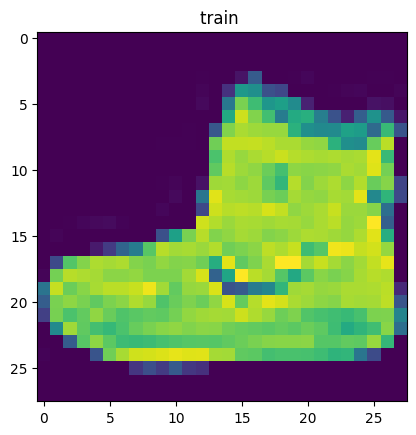

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download=True,
    transform = transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False ,
    download=True ,
    transform = ToTensor(),
    target_transform=None

)

import matplotlib.pyplot as plt
img , labels  = train_data[0]
print(f"img size  : {img.shape}")
plt.imshow(img.squeeze())
plt.title("train ")

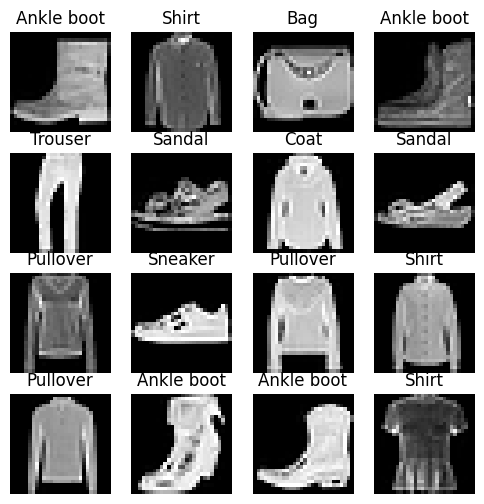

In [ ]:
torch.manual_seed(42)
plt.figure(figsize = (6,6))
rows , cols = 4,4
class_names = [name for name , _ in sorted(train_data.class_to_idx.items(), key = lambda item: item [1] )]
#class_names = train_data.class_to_idx
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0 , len(train_data) , size = [1]).item()
    img , labels = train_data[random_idx]
    plt.subplot(rows , cols , i)
    plt.imshow(img.squeeze(), cmap = "gray")
    plt.title(class_names[labels])
    plt.axis(False)

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE  = 32
train_dataloader = DataLoader(
    dataset = train_data,
    shuffle = True ,
    batch_size = BATCH_SIZE
)
test_dataloader = DataLoader(
    dataset = test_data ,
    shuffle = False ,
    batch_size = BATCH_SIZE
)
train_dataloader , test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x79861ef16420>,
 <torch.utils.data.dataloader.DataLoader at 0x79861ed5d3d0>)

In [ ]:
train_features_batch , train_labels_batch = next(iter(train_dataloader))

<Figure size 400x500 with 0 Axes>

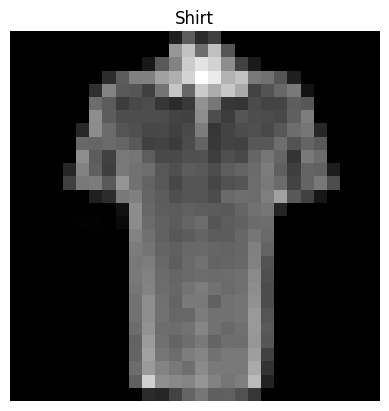

<Figure size 400x500 with 0 Axes>

In [ ]:
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch) , size = (1,)).item()
img , labels = train_features_batch[random_idx] , train_labels_batch[random_idx]
plt.imshow(img.squeeze() , cmap = "gray")
plt.title(class_names[labels])
plt.axis(False)
plt.figure(figsize = (4,5))

In [ ]:
flatten_model = nn.Flatten
x = train_features_batch[0]
output = flatten_model(x)

In [ ]:
class FashionMNISTModel(nn.Module):
  def __init__(self , input_size = int , output_size = int , hidden_unit= int ):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_size , out_features = hidden_unit ),
        nn.Linear(in_features= hidden_unit  , out_features = hidden_unit ),
        nn.Linear(in_features= hidden_unit , out_features = hidden_unit )
    )
  def forward (self , x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model_0 = FashionMNISTModel(
    input_size = 28*28,
    output_size = len(class_names),
    hidden_unit = 10
)
model_0

FashionMNISTModel(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
from pathlib import Path
import requests

file_name = "helper_functions.py"

if Path(file_name).is_file():
    print(f"{file_name} already exists.")
else:
    print(f"Downloading {file_name}...")
    # Use the raw GitHub URL for the helper_functions.py file
    raw_url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py"
    response = requests.get(raw_url)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(file_name, "wb") as f:
        f.write(response.content)
    print("Download complete.")



helper_functions.py already exists.


In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)

In [ ]:
from timeit import default_timer as timer

def print_train_time (
    start = float ,
    end = float ,
    device : torch.device = None
):

   total_time = end - start
   print(f"total time by trian data: {device} : {total_time}")



In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)
time_taken_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch+1}")

  # Training
  train_loss = 0
  train_acc = 0
  model_0.train()
  for batch, (X, y) in enumerate(train_dataloader):
    y_logits = model_0(X) # Get raw logits
    loss = loss_fn(y_logits, y) # Calculate loss
    train_loss += loss.item() # Accumulate loss
    train_acc += accuracy_fn(y, y_logits.argmax(dim=1)) # Accumulate accuracy with positional arguments

    optimizer.zero_grad() # Zero gradients
    loss.backward() # Backpropagation
    optimizer.step() # Update weights

  # Average train loss and accuracy for the epoch
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  # Testing
  test_loss = 0
  test_acc = 0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      test_logits = model_0(X_test) # Get raw logits for test data
      test_loss += loss_fn(test_logits, y_test).item() # Accumulate test loss
      test_acc += accuracy_fn(y_test, test_logits.argmax(dim=1)) # Accumulate test accuracy with positional arguments

  # Average test loss and accuracy for the epoch
  test_loss /= len(test_dataloader)
  test_acc /= len(test_dataloader)

  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1
Train Loss: 0.9433 | Train Acc: 66.73% | Test Loss: 0.6601 | Test Acc: 75.74%
Epoch: 2
Train Loss: 0.5870 | Train Acc: 79.06% | Test Loss: 0.5723 | Test Acc: 79.82%
Epoch: 3
Train Loss: 0.5315 | Train Acc: 81.32% | Test Loss: 0.5447 | Test Acc: 80.86%


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

train_data = datasets.FashionMNIST(
    root = "data",
    train = True ,
    download = True ,
    transform = ToTensor(),
    target_transform  = None

)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False ,
    download = True ,
    transform = ToTensor(),
    target_transform  = None

)







from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_dataloader = DataLoader(
    dataset = train_data ,
    shuffle = True ,
    batch_size = 32
)

test_dataloader = DataLoader(
    dataset = test_data ,
    shuffle = False ,
    batch_size = BATCH_SIZE
)

train_features_batch , train_label_batch = next(iter(train_dataloader))
train_features_batch.shape , train_label_batch.shape

In [ ]:
flatten_model_0 = nn.Flatten
x = train_features_batch
output = flatten_model_0(x)


In [ ]:
class FashionMNISTModel(nn.Module):
  def __init__(self , input_layer = int , output_layer = int , hidden_unit = int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_layer , out_features= hidden_unit),
        nn.Linear(in_features =hidden_unit, out_features= hidden_unit),
        nn.Linear(in_features = hidden_unit , out_features= output_layer),
    )

  def forward (self , x):
    return self.layer_stack(x)

In [ ]:
class_names = [name for name , _ in sorted(train_data.class_to_idx.items(), key = lambda item: item [1] )]



model_0 = FashionMNISTModel(
    input_layer = 28*28,
    hidden_unit = 10 ,
    output_layer = len(class_names)
)
model_0

In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters())


In [ ]:
from timeit import default_timer as timer
def print_train_time(
    start = float ,
    end   = float ,
    ):

  total_time = end - start
  print(f"train timer taken: {total_time}")


In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)
# Store start time for the entire training process
start_time_total = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"EPoch : {epoch}")

  # Training loop
  train_loss = 0
  train_acc = 0
  model_0.train() # Set model to training mode
  for batch , (X, y) in enumerate(train_dataloader): # Use X, y for consistency with earlier cells
    y_logits = model_0(X)
    loss = loss_fn(y_logits , y) # Correctly calculate loss
    train_loss += loss.item() # Accumulate loss for averaging later
    train_acc += accuracy_fn(y_true=y , y_pred=y_logits.argmax(dim=1)) # Accumulate accuracy

    optimizer.zero_grad() # Zero gradients
    loss.backward() # Backpropagation
    optimizer.step() # Update weights

  # Average train loss and accuracy for the epoch (outside the batch loop)
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  # Testing loop
  test_loss = 0
  test_acc = 0
  model_0.eval() # Set model to evaluation mode
  with torch.inference_mode(): # Turn off gradient tracking for inference
    for X_test ,y_test in test_dataloader: # Use X_test, y_test for consistency
      test_logits = model_0(X_test)
      test_loss += loss_fn(test_logits , y_test).item() # Accumulate test loss
      test_acc += accuracy_fn(y_true=y_test , y_pred=test_logits.argmax(dim=1)) # Accumulate test accuracy

  # Average test loss and accuracy for the epoch (outside the test batch loop)
  test_loss /= len(test_dataloader)
  test_acc /= len(test_dataloader)

  # Print results once per epoch
  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

# Calculate and print total training time
end_time_total = timer()
print_train_time(start=start_time_total, end=end_time_total)

In [ ]:
class FashionMNISTModelv1(nn.Module):
  def __init__(self , input_shape= int , output_shape = int , hidden_unit = int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape , out_features = hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features = hidden_unit, out_features = output_shape),
        nn.ReLU()
    )

  def forward (self , x):
    return self.layer_stack(x)


model_1 = FashionMNISTModelv1(
    input_shape = 784 ,
    hidden_unit = 10 ,
    output_shape = len(class_names)
)
model_1

In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters() , lr = 0.10)


In [ ]:
from tqdm.auto import tqdm
torch.manual_seed(42)

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"epochs : {epoch}")
  train_loss = 0
  train_acc = 0
  model_1.train()
  for batch,(x ,y) in enumerate(train_dataloader):
    y_pred = model_1(x)
    loss = loss_fn(y_pred , y)
    train_loss += loss.item() # Corrected loss accumulation
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 400 == 0:
      print(f"look at {batch * len(x)} / {len(train_dataloader.dataset)}")

  # Average train loss and accuracy for the epoch (moved outside batch loop)
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  test_loss =0
  test_acc = 0

  model_1.eval()
  with torch.inference_mode():
    for x_test , y_test in test_dataloader:
      test_pred = model_1(x_test)
      test_loss += loss_fn(test_pred , y_test).item() # Corrected test loss accumulation
      test_acc += accuracy_fn(y_true=y_test , y_pred=test_pred.argmax(dim=1)) # Corrected function name

  # Average test loss and accuracy for the epoch (moved outside test loop)
  test_loss /= len(test_dataloader)
  test_acc /= len(test_dataloader)

  # Print results once per epoch
  print(f"train_loss : {train_loss:.5f} , train_acc : {train_acc:.2f} % | test_loss : {test_loss:.5f} , test_acc : {test_acc:.2f}%")

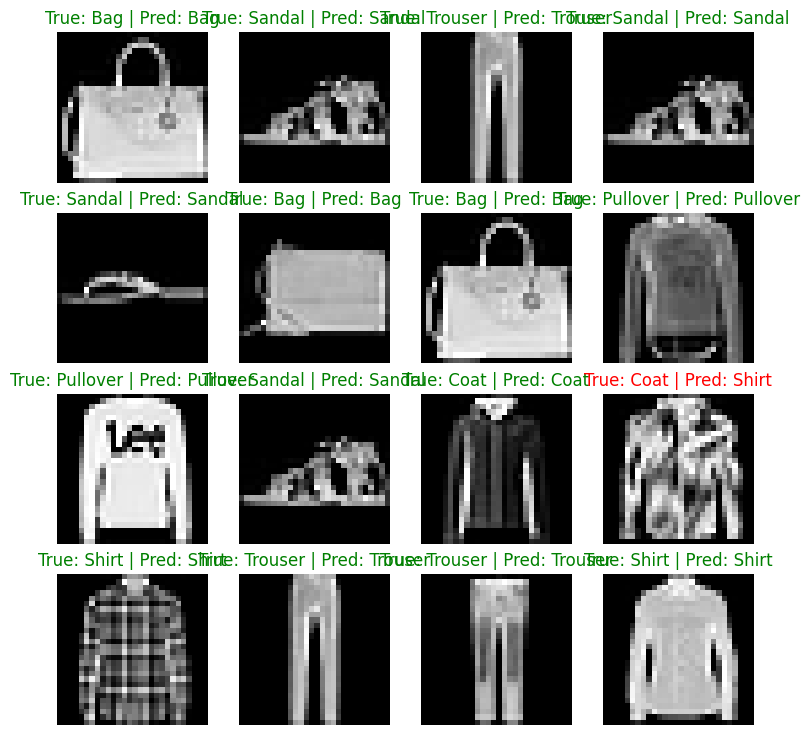

In [ ]:
import matplotlib.pyplot as plt
import random
import torch

# Put model in evaluation mode
model_0.eval()

# Get a batch of test samples
X_test, y_test = next(iter(test_dataloader))

# Make predictions with model_1
with torch.inference_mode():
    test_preds = model_0(X_test)

# Convert logits to prediction labels
test_preds_labels = test_preds.argmax(dim=1)

# Plot random samples
plt.figure(figsize=(9, 9))
rows = 4
cols = 4
for i in range(1, rows * cols + 1):
    random_idx = random.randint(0, len(X_test) - 1)
    img, true_label, predicted_label = X_test[random_idx], y_test[random_idx], test_preds_labels[random_idx]
    plt.subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[predicted_label]}",
              color="green" if true_label == predicted_label else "red")
    plt.axis(False)

In [ ]:
class FashionMNISTv2(nn.Module):
  def __init__(self , input = int , output = int , hidden_unit = int ):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input , out_channels = hidden_unit,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_unit , out_channels = hidden_unit,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2)
    )
    self.classification = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_unit * 7 * 7, out_features = output) # Corrected in_features to match flattened output
    )

  def forward (self , x):
    x =self.conv_block_1(x)
    #print(f"output of convblock_1 : {x.shape}")
    x = self.conv_block_2(x)
    #print(f"output of convblock_1 : {x.shape}")
    x =self.classification(x)
    return(x)

In [ ]:
class_names = [name for name , _ in sorted(train_data.class_to_idx.items(), key = lambda item: item [1] )]


torch.manual_seed(42)
model_01 =  FashionMNISTv2(
    input = 1 ,
    hidden_unit = 10 ,
    output = len(class_names)
)

In [ ]:
model_01(img.unsqueeze(0))

In [ ]:
torch.manual_seed(42)

image = torch.randn(size = (3 ,64,32,64))
test_image = image[0]
test_image

tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [ 0.6107,  0.2143, -0.1747,  ...,  0.6600, -0.1619,  0.8861],
         [ 0.5484,  0.4577,  0.9677,  ..., -0.3452, -0.7288, -1.4958],
         [ 0.7351, -0.2693,  0.4509,  ..., -0.0334, -0.8276, -0.3524]],

        [[-0.6002, -0.0580,  0.2975,  ...,  0.4989, -1.0029,  0.0679],
         [-0.5346, -1.4052,  1.8912,  ...,  1.1301, -0.3334,  0.8936],
         [-1.4336, -0.8756,  0.0094,  ..., -0.3191,  0.9801,  0.1196],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1

In [ ]:
Conv_layer = nn.Conv2d(in_channels=1 , out_channels = 10 , kernel_size = 3 , stride = 1 , padding = 0)
Conv_layer

In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_01.parameters() , lr = 0.01
                            )

In [ ]:
## training loop
from tqdm.auto import tqdm
#torch.manual_seed(42)
epochs = 3


for epoch in tqdm(range(epochs)):
  print(f"epochs : {epoch}")

  train_loss = 0
  train_acc = 0
  model_01.train()
  for batch , (X, y) in enumerate(train_dataloader):
    y_pred = model_01(X)
    loss = loss_fn(y_pred , y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y , y_pred.argmax(dim = 1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # Average train loss and accuracy for the epoch (outside the batch loop)
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  test_loss = 0
  test_acc = 0

  model_01.eval()
  with torch.inference_mode():
    for x_test , y_test in test_dataloader:
      y_pred = model_01(x_test)
      # Corrected: Call .item() method
      test_loss += loss_fn(y_pred , y_test).item()
      test_acc += accuracy_fn(y_test , y_pred.argmax(dim =1 ))

  # Average test loss and accuracy for the epoch (outside the test loop)
  test_loss /= len(test_dataloader)
  test_acc /= len(test_dataloader)

  # Print results once per epoch
  print(f"train_loss : {train_loss:.5f} , train_acc : {train_acc:.2f} % | test_loss : {test_loss:.5f} , test_acc : {test_acc:.2f}%")

  0%|          | 0/3 [00:00<?, ?it/s]

epochs : 0
train_loss : 0.44277 , train_acc : 84.38 % | test_loss : 0.43645 , test_acc : 84.33%
epochs : 1
train_loss : 0.41884 , train_acc : 85.06 % | test_loss : 0.42036 , test_acc : 85.43%
epochs : 2
train_loss : 0.40074 , train_acc : 85.79 % | test_loss : 0.42066 , test_acc : 84.35%


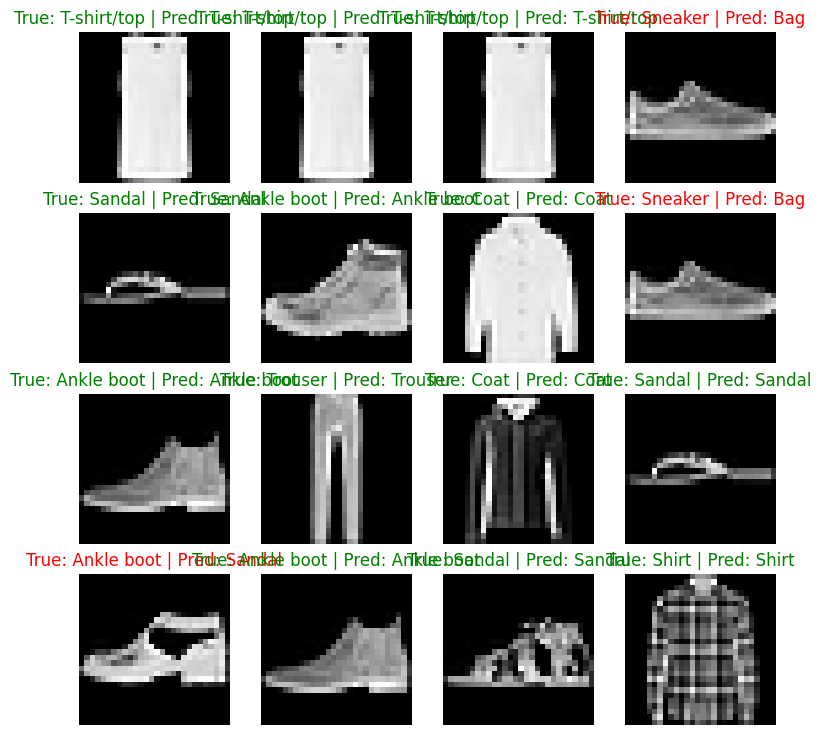

In [ ]:

model_01.eval()
x_test , y_test = next(iter(test_dataloader))
with torch.inference_mode():
  y_pred = model_01(x_test)

  y_pred_label = y_pred.argmax(dim =1 )


  plt.figure(figsize=(9,9))
  rows , cols  = 4,4
  for i in range(1 , rows * cols + 1):
    random_idx = torch.randint(0 , len(x_test), size=[1]).item() # Corrected random_idx generation
    img , true_label_val , predicted_label_val = x_test[random_idx] , y_test[random_idx] , y_pred_label[random_idx] # Renamed to avoid confusion and used y_pred_label
    plt.subplot(rows , cols , i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"True: {class_names[true_label_val]} | Pred: {class_names[predicted_label_val]}", # Used correct class_names indexing
                color="green" if true_label_val == predicted_label_val else "red")
    plt.axis(False)

In [ ]:
from  tqdm.auto import tqdm
y_pred_list = [] # Initialize as a list
model_01.eval()
with torch.inference_mode():
   for X , y in tqdm(test_dataloader ,desc = "making_prediction"):
    y_logits = model_01(X)
    # Compute predictions for the current batch and append to the list
    batch_preds = torch.softmax(y_logits.squeeze(), dim=0).argmax(dim =1 )
    y_pred_list.append(batch_preds)

# Concatenate all predicted tensors after the loop
y_pred_tensor = torch.cat(y_pred_list)
y_pred_tensor

In [ ]:
try:
  import torchmetrics , mlxtend
  print(f"matrics version  : {metrics.__version__}")
  assert int (mlxtend.__version__.split)('.') [1] >= 19

except:
  !pip install torchmetrics -U mlxtend

In [ ]:
class_names = [name for name , _ in sorted(train_data.class_to_idx.items(), key = lambda item: item [1] )]

import torchmetrics , mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes= len(class_names), task='multiclass' )
confmat_tensor = confmat(preds = y_pred_tensor,
                         target = test_data.targets)

fig  , ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names = class_names,
    figsize = (10,7)
)